In [3]:
#Importing libraries
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os

In [4]:
#Landmark Normalization Function
def normalize_landmarks(landmarks):
    """
    landmarks: list of (x,y) from mediapipe
    returns: flattened normalized vector (42 values)
    
    """
    pts = np.array(landmarks, dtype=np.float32)

    origin = pts[0].copy()
    pts -= origin

    max_dist = np.linalg.norm(pts, axis=1).max()
    if max_dist > 1e-6:
        pts /= max_dist

    ref = pts[9]
    angle = np.arctan2(ref[1], ref[0])
    cos, sin = np.cos(-angle), np.sin(-angle)
    R = np.array([[cos, -sin], [sin, cos]], dtype=np.float32)
    pts = pts.dot(R.T)

    return pts.flatten()

In [5]:
#Dataset Feature Extraction
#MediaPipe Initialization
mp_hands = mp.solutions.hands

In [7]:
#Extract Hand Features from Images
dataset_dir = r"D:\Gesture Image Data"   
out_csv = "features.csv"

rows = []

with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands:
    for class_name in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.lower().endswith((".jpg",".jpeg",".png"))]
        print(f"[{class_name}] {len(files)} images")

        for fn in files:
            img = cv2.imread(os.path.join(class_path, fn))
            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            results = hands.process(img_rgb)

            if not results.multi_hand_landmarks:
                continue

            lm = [(p.x, p.y) for p in results.multi_hand_landmarks[0].landmark]
            feats = normalize_landmarks(lm)

            rows.append([class_name] + feats.tolist())

df = pd.DataFrame(rows, columns=["label"]+[f"x{i}" for i in range(21)]+[f"y{i}" for i in range(21)])
df.to_csv(out_csv, index=False)

print("Saved", out_csv, "with", len(df), "samples")


[0] 70 images
[1] 70 images
[2] 70 images
[3] 70 images
[4] 70 images
[5] 70 images
[6] 70 images
[7] 70 images
[8] 70 images
[9] 70 images
[A] 112 images
[B] 112 images
[C] 112 images
[D] 112 images
[E] 112 images
[F] 112 images
[G] 112 images
[H] 112 images
[I] 116 images
[J] 108 images
[K] 112 images
[L] 112 images
[M] 112 images
[N] 112 images
[O] 112 images
[P] 112 images
[Q] 112 images
[R] 112 images
[S] 112 images
[T] 107 images
[U] 112 images
[V] 112 images
[W] 112 images
[X] 112 images
[Y] 112 images
[Z] 112 images
Saved features.csv with 2641 samples


In [8]:
#Model Training
#Load Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("features.csv")

X = df.drop("label", axis=1).values
y = df["label"].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Classes:", encoder.classes_)


Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H'
 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [9]:
#Train RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("RandomForest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

joblib.dump(rf_model, "sign_rf_model.pkl")


RandomForest Accuracy: 0.9659735349716446
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       1.00      1.00      1.00        12
           2       0.90      0.90      0.90        10
           3       1.00      1.00      1.00        14
           4       0.93      0.93      0.93        14
           5       0.93      0.93      0.93        14
           6       1.00      0.90      0.95        10
           7       0.93      1.00      0.96        13
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        14
           A       0.85      1.00      0.92        11
           B       1.00      1.00      1.00        21
           C       1.00      1.00      1.00        14
           D       1.00      0.95      0.98        21
           E       1.00      1.00      1.00        12
           F       1.00      1.00      1.00        22
           G       1.00      0.95      

['sign_rf_model.pkl']

In [10]:
#Train KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=encoder.classes_))

joblib.dump(knn_model, "sign_knn_model.pkl")
joblib.dump(encoder, "label_encoder.pkl")


KNN Accuracy: 0.941398865784499
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.86      1.00      0.92        12
           2       0.90      0.90      0.90        10
           3       1.00      1.00      1.00        14
           4       1.00      0.93      0.96        14
           5       0.93      1.00      0.97        14
           6       0.88      0.70      0.78        10
           7       0.93      1.00      0.96        13
           8       1.00      0.92      0.96        12
           9       1.00      1.00      1.00        14
           A       1.00      0.82      0.90        11
           B       1.00      1.00      1.00        21
           C       0.74      1.00      0.85        14
           D       0.87      0.95      0.91        21
           E       1.00      1.00      1.00        12
           F       1.00      1.00      1.00        22
           G       1.00      0.89      0.94      

['label_encoder.pkl']

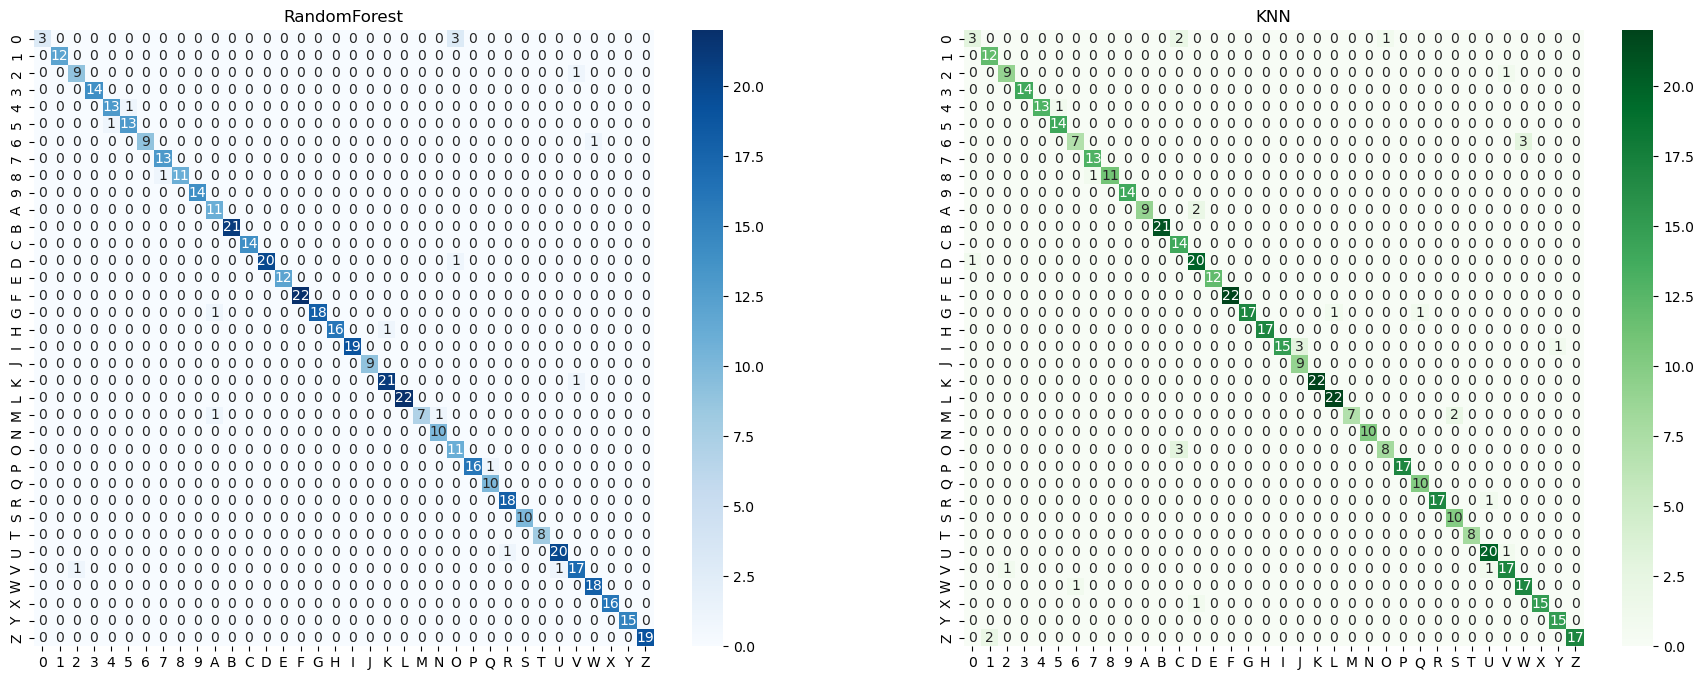

In [11]:
#Evaluation
#Confusion Matrices
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_, ax=axes[0])
axes[0].set_title("RandomForest")

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_, ax=axes[1])
axes[1].set_title("KNN")

plt.show()


In [12]:
#Real-Time Sign Recognition
import cv2
import mediapipe as mp
from collections import deque, Counter

model = joblib.load("sign_rf_model.pkl")
encoder = joblib.load("label_encoder.pkl")

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

prediction_window = deque(maxlen=10)
cap = cv2.VideoCapture(0)

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
) as hands:

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                lm = [(p.x, p.y) for p in hand_landmarks.landmark]
                feats = normalize_landmarks(lm).reshape(1, -1)

                pred = model.predict(feats)[0]
                label = encoder.inverse_transform([pred])[0]

                prediction_window.append(label)
                stable_label = Counter(prediction_window).most_common(1)[0][0]

                mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
                cv2.putText(frame, f"Predicted: {stable_label}",
                            (10, 50), cv2.FONT_HERSHEY_SIMPLEX,
                            1, (0, 255, 0), 2)

        cv2.imshow("Sign Language Recognition", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
